In [1]:
import matplotlib
from matplotlib import rc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

rc('text', usetex=False)
sns.set_context('paper', font_scale=2.0)
sns.set_style('whitegrid')

In [2]:
rx5500_gold = pd.read_csv("./pointer_chasing_gold_rx5500.csv", index_col=0)
r9nano_gold = pd.read_csv("./pointer_chasing_gold_r9nano.csv", index_col=0)
mi100_gold = pd.read_csv("./pointer_chasing_gold_MI100.csv", index_col=0)

In [3]:
rx5500_gold

,benchmark,env,param1,param2,time
0,pointer_chasing,native,32,1,6.356170e+09
1,pointer_chasing,native,64,1,6.355913e+09
2,pointer_chasing,native,128,1,6.355961e+09
3,pointer_chasing,native,256,1,6.356248e+09
4,pointer_chasing,native,512,1,6.355481e+09
5,pointer_chasing,native,1024,1,6.354488e+09
6,pointer_chasing,native,2048,1,6.354098e+09
7,pointer_chasing,native,4096,1,6.353639e+09
8,pointer_chasing,native,8192,1,6.354159e+09
9,pointer_chasing,native,16384,1,6.354031e+09


In [4]:
r9nano_gold['gpu']="R9Nano"
rx5500_gold['gpu'] = "RX5500XT"
mi100_gold['gpu']="MI100"

In [5]:
rx5500_gold

,benchmark,env,param1,param2,time,gpu
0,pointer_chasing,native,32,1,6.356170e+09,RX5500XT
1,pointer_chasing,native,64,1,6.355913e+09,RX5500XT
2,pointer_chasing,native,128,1,6.355961e+09,RX5500XT
3,pointer_chasing,native,256,1,6.356248e+09,RX5500XT
4,pointer_chasing,native,512,1,6.355481e+09,RX5500XT
5,pointer_chasing,native,1024,1,6.354488e+09,RX5500XT
6,pointer_chasing,native,2048,1,6.354098e+09,RX5500XT
7,pointer_chasing,native,4096,1,6.353639e+09,RX5500XT
8,pointer_chasing,native,8192,1,6.354159e+09,RX5500XT
9,pointer_chasing,native,16384,1,6.354031e+09,RX5500XT


In [6]:
rx5500_gold['time'] = rx5500_gold['time']/100000000
r9nano_gold['time'] = r9nano_gold['time']/100000000
mi100_gold['time'] = mi100_gold['time']/100000000

rx5500_gold['cycle'] = rx5500_gold['time']/1e9*(1607*1024*1024)
r9nano_gold['cycle'] = r9nano_gold['time']/1e9*(1000*1024*1024)
mi100_gold['cycle'] = mi100_gold['time']/1e9*(1500*1024*1024)

In [7]:
rx5500_gold

,benchmark,env,param1,param2,time,gpu,cycle
0,pointer_chasing,native,32,1,63.561699,RX5500XT,107.105380
1,pointer_chasing,native,64,1,63.559127,RX5500XT,107.101046
2,pointer_chasing,native,128,1,63.559606,RX5500XT,107.101854
3,pointer_chasing,native,256,1,63.562481,RX5500XT,107.106698
4,pointer_chasing,native,512,1,63.554814,RX5500XT,107.093779
5,pointer_chasing,native,1024,1,63.544880,RX5500XT,107.077040
6,pointer_chasing,native,2048,1,63.540977,RX5500XT,107.070463
7,pointer_chasing,native,4096,1,63.536387,RX5500XT,107.062728
8,pointer_chasing,native,8192,1,63.541591,RX5500XT,107.071497
9,pointer_chasing,native,16384,1,63.540309,RX5500XT,107.069337


In [8]:
all_gold = pd.concat([rx5500_gold, r9nano_gold, mi100_gold])

In [9]:
all_gold

,benchmark,env,param1,param2,time,gpu,cycle
0,pointer_chasing,native,32,1,63.561699,RX5500XT,107.105380
1,pointer_chasing,native,64,1,63.559127,RX5500XT,107.101046
2,pointer_chasing,native,128,1,63.559606,RX5500XT,107.101854
3,pointer_chasing,native,256,1,63.562481,RX5500XT,107.106698
4,pointer_chasing,native,512,1,63.554814,RX5500XT,107.093779
...,...,...,...,...,...,...,...
16,pointer_chasing,native,2097152,1,200.366691,MI100,315.149555
17,pointer_chasing,native,4194304,1,202.871366,MI100,319.089068
18,pointer_chasing,native,8388608,1,230.505535,MI100,362.553857
19,pointer_chasing,native,16777216,1,311.800419,MI100,490.419654


In [10]:
r9nano_sim = pd.read_csv('results_r9nano_cal.csv', index_col=0)
r9nano_sim = r9nano_sim.drop(columns=['index'])
r9nano_sim.columns = ['benchmark', 'param1', 'time']
r9nano_sim['env']='sim'
r9nano_sim['gpu']='R9Nano'
r9nano_sim['time']*=100
r9nano_sim

,benchmark,param1,time,env,gpu
0,pointer_chasing,32,172.000752,sim,R9Nano
1,pointer_chasing,64,172.000752,sim,R9Nano
2,pointer_chasing,128,172.000786,sim,R9Nano
3,pointer_chasing,256,172.000854,sim,R9Nano
4,pointer_chasing,512,172.000991,sim,R9Nano
5,pointer_chasing,1024,172.001265,sim,R9Nano
6,pointer_chasing,2048,172.001812,sim,R9Nano
7,pointer_chasing,4096,172.002906,sim,R9Nano
8,pointer_chasing,8192,172.005177,sim,R9Nano
9,pointer_chasing,16384,172.009719,sim,R9Nano


In [11]:
rx5500_sim = pd.read_csv('results_rx5500xt_cal.csv', index_col=0)
rx5500_sim = rx5500_sim.drop(columns=['index'])
rx5500_sim.columns = ['benchmark', 'param1', 'time']
rx5500_sim['env']='sim'
rx5500_sim['gpu']='RX5500XT'
rx5500_sim['time']*=100
rx5500_sim

,benchmark,param1,time,env,gpu
0,pointer_chasing,32,63.473108,sim,RX5500XT
1,pointer_chasing,64,63.473108,sim,RX5500XT
2,pointer_chasing,128,63.473108,sim,RX5500XT
3,pointer_chasing,256,63.473177,sim,RX5500XT
4,pointer_chasing,512,63.473316,sim,RX5500XT
5,pointer_chasing,1024,63.473594,sim,RX5500XT
6,pointer_chasing,2048,63.474149,sim,RX5500XT
7,pointer_chasing,4096,63.475260,sim,RX5500XT
8,pointer_chasing,8192,63.477564,sim,RX5500XT
9,pointer_chasing,16384,63.482171,sim,RX5500XT


In [13]:
mi100_sim = pd.read_csv('results_mi100_cal.csv', index_col=0)
mi100_sim = mi100_sim.drop(columns=['index'])
mi100_sim.columns = ['benchmark', 'param1', 'time']
mi100_sim['env']='sim'
mi100_sim['gpu']='MI100'
mi100_sim['time']*=100
mi100_sim

,benchmark,param1,time,env,gpu
0,pointer_chasing,32,116.667295,sim,MI100
1,pointer_chasing,64,116.667295,sim,MI100
2,pointer_chasing,128,116.667317,sim,MI100
3,pointer_chasing,256,116.667360,sim,MI100
4,pointer_chasing,512,116.667446,sim,MI100
5,pointer_chasing,1024,116.667618,sim,MI100
6,pointer_chasing,2048,116.667962,sim,MI100
7,pointer_chasing,4096,116.668650,sim,MI100
8,pointer_chasing,8192,116.670110,sim,MI100
9,pointer_chasing,16384,116.673028,sim,MI100


In [14]:
all_data = pd.concat([
	r9nano_sim, r9nano_gold, 
	rx5500_sim, rx5500_gold, 
	mi100_sim, mi100_gold,
])
all_data

,benchmark,param1,time,env,gpu,param2,cycle
0,pointer_chasing,32,172.000752,sim,R9Nano,NaN,NaN
1,pointer_chasing,64,172.000752,sim,R9Nano,NaN,NaN
2,pointer_chasing,128,172.000786,sim,R9Nano,NaN,NaN
3,pointer_chasing,256,172.000854,sim,R9Nano,NaN,NaN
4,pointer_chasing,512,172.000991,sim,R9Nano,NaN,NaN
...,...,...,...,...,...,...,...
16,pointer_chasing,2097152,200.366691,native,MI100,1.0,315.149555
17,pointer_chasing,4194304,202.871366,native,MI100,1.0,319.089068
18,pointer_chasing,8388608,230.505535,native,MI100,1.0,362.553857
19,pointer_chasing,16777216,311.800419,native,MI100,1.0,490.419654


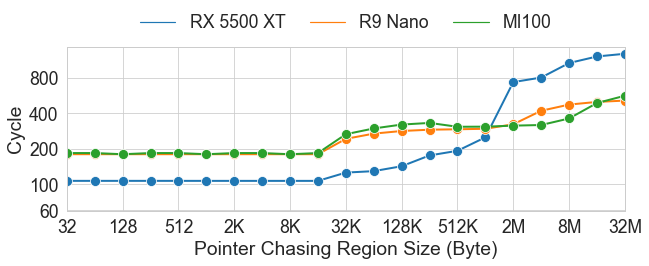

In [15]:
fig, ax = plt.subplots(figsize=(10, 3))

sns.lineplot(x='param1', y='cycle', hue='gpu', 
    data = all_gold,
    linewidth=2,
    marker='o', markersize=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(32,2**25)

ax.set_xticks([32, 128, 512, 2048, 8192, 32768, 131072, 524288, 2097152, 8388608, 33554432])
ax.set_xticklabels(["32", "128", "512", "2K", "8K", "32K", "128K", "512K", "2M", "8M", "32M"])


ax.set_yticks([60, 100, 200, 400, 800])
ax.set_yticklabels(["60", "100", "200", "400", "800"])
# ax.set_ylim(60, 75)


handles, labels = ax.get_legend_handles_labels()
labels=['RX 5500 XT', 'R9 Nano', 'MI100']
ax.legend(handles, labels, 
          frameon=False,
          fancybox=None, 
          columnspacing=1.4,
          facecolor=None, edgecolor=None, 
          bbox_to_anchor=(0.5, 1.15), loc=10, ncol=3)


ax.set_xlabel("Pointer Chasing Region Size (Byte)")
ax.set_ylabel("Cycle")

plt.savefig('pointer_chasing.pdf', bbox_inches='tight')
plt.savefig('pointer_chasing.png', dpi=600, bbox_inches='tight')

plt.show()
plt.close()



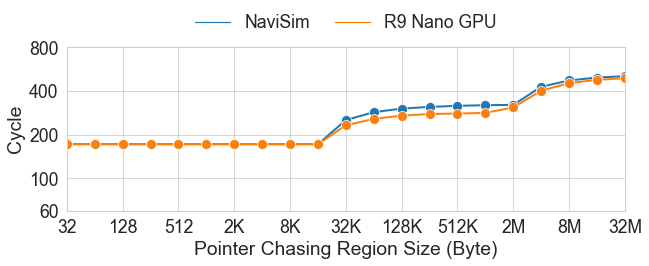

In [16]:
fig, ax = plt.subplots(figsize=(10, 3))

sns.lineplot(x='param1', y='time', hue='env', 
    data = all_data[all_data['gpu']=='R9Nano'],
    linewidth=2,
    marker='o', markersize=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(32,2**25)

ax.set_xticks([32, 128, 512, 2048, 8192, 32768, 131072, 524288, 2097152, 8388608, 33554432])
ax.set_xticklabels(["32", "128", "512", "2K", "8K", "32K", "128K", "512K", "2M", "8M", "32M"])


ax.set_yticks([60, 100, 200, 400, 800])
ax.set_yticklabels(["60", "100", "200", "400", "800"])
# ax.set_ylim(60, 75)
# handles, labels = ax.get_legend_handles_labels()
labels=['NaviSim', 'R9 Nano GPU',]
ax.legend(handles, labels, 
          frameon=False,
          fancybox=None, 
          columnspacing=1.4,
          facecolor=None, edgecolor=None, 
          bbox_to_anchor=(0.5, 1.15), loc=10, ncol=3)


ax.set_xlabel("Pointer Chasing Region Size (Byte)")
ax.set_ylabel("Cycle")

plt.savefig('pointer_chasing_r9nano.pdf', bbox_inches='tight')
plt.savefig('pointer_chasing_r9nano.png', dpi=600, bbox_inches='tight')

plt.show()
plt.close()

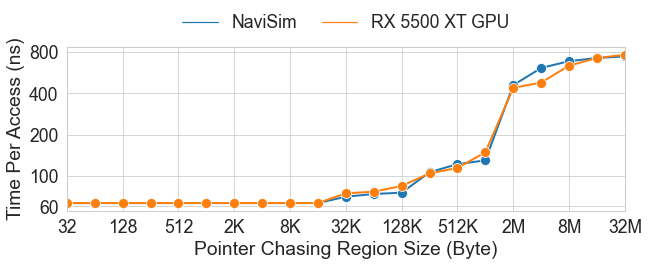

In [17]:
fig, ax = plt.subplots(figsize=(10, 3))

sns.lineplot(x='param1', y='time', hue='env', 
    data = all_data[all_data['gpu']=='RX5500XT'],
    linewidth=2,
    marker='o', markersize=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(32,2**25)

ax.set_xticks([32, 128, 512, 2048, 8192, 32768, 131072, 524288, 2097152, 8388608, 33554432])
ax.set_xticklabels(["32", "128", "512", "2K", "8K", "32K", "128K", "512K", "2M", "8M", "32M"])


ax.set_yticks([60, 100, 200, 400, 800])
ax.set_yticklabels(["60", "100", "200", "400", "800"])
# ax.set_ylim(60, 75)
# handles, labels = ax.get_legend_handles_labels()
labels=['NaviSim', 'RX 5500 XT GPU',]
ax.legend(handles, labels, 
          frameon=False,
          fancybox=None, 
          columnspacing=1.4,
          facecolor=None, edgecolor=None, 
          bbox_to_anchor=(0.5, 1.15), loc=10, ncol=3)


ax.set_xlabel("Pointer Chasing Region Size (Byte)")
ax.set_ylabel("Time Per Access (ns)")

plt.savefig('pointer_chasing_rx5500.pdf', bbox_inches='tight')
plt.savefig('pointer_chasing_rx5500.png', dpi=600, bbox_inches='tight')

plt.show()
plt.close()

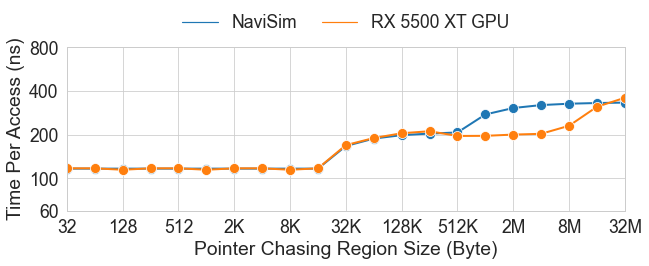

In [18]:
fig, ax = plt.subplots(figsize=(10, 3))

sns.lineplot(x='param1', y='time', hue='env', 
    data = all_data[all_data['gpu']=='MI100'],
    linewidth=2,
    marker='o', markersize=10)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(32,2**25)

ax.set_xticks([32, 128, 512, 2048, 8192, 32768, 131072, 524288, 2097152, 8388608, 33554432])
ax.set_xticklabels(["32", "128", "512", "2K", "8K", "32K", "128K", "512K", "2M", "8M", "32M"])


ax.set_yticks([60, 100, 200, 400, 800])
ax.set_yticklabels(["60", "100", "200", "400", "800"])
# ax.set_ylim(60, 75)
# handles, labels = ax.get_legend_handles_labels()
labels=['NaviSim', 'MI 100 GPU',]
ax.legend(handles, labels, 
          frameon=False,
          fancybox=None, 
          columnspacing=1.4,
          facecolor=None, edgecolor=None, 
          bbox_to_anchor=(0.5, 1.15), loc=10, ncol=3)


ax.set_xlabel("Pointer Chasing Region Size (Byte)")
ax.set_ylabel("Time Per Access (ns)")

plt.savefig('pointer_chasing_rx5500.pdf', bbox_inches='tight')
plt.savefig('pointer_chasing_rx5500.png', dpi=600, bbox_inches='tight')

plt.show()
plt.close()